In [9]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 1000

data = {
    'person_age': np.random.randint(18, 70, size=n_samples),
    'person_income': np.random.randint(20000, 150000, size=n_samples),
    'loan_amnt': np.random.randint(2000, 50000, size=n_samples),
    'loan_int_rate': np.random.uniform(5.0, 22.0, size=n_samples),
    'loan_status': np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15])
}

df = pd.DataFrame(data)

print("Starting 5 rows")
print(df.head())

print("\n Target Variable Count (Imbalance check)")
print(df['loan_status'].value_counts())

Starting 5 rows
   person_age  person_income  loan_amnt  loan_int_rate  loan_status
0          56         125186      20546      17.717244            0
1          69          54674      21129      18.800086            0
2          46          55854       3591      16.160136            1
3          32          66271      13303       7.177628            1
4          60          93688      32561      10.750548            0

 Target Variable Count (Imbalance check)
loan_status
0    864
1    136
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

# 1. Features (X) & Target (y) separate
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# 2. split into train & test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(
f"X_train shape: {X_train.shape}, y_train class ratio: {np.bincount(y_train)}")
print(f"X_test shape: {X_test.shape}, y_test class ratio: {np.bincount(y_test)}")

X_train shape: (800, 4), y_train class ratio: [691 109]
X_test shape: (200, 4), y_test class ratio: [173  27]


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Model Initialize & Training
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# 3. Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Model trained")

Logistic Regression Model trained


In [12]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report

# 1. F1-Score & ROC-AUC 
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_pred_proba_lr)

print(f"Logistic Regression F1-Score: {f1:.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc:.4f}")

# 2. Detail report
print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Logistic Regression F1-Score: 0.0000
Logistic Regression ROC-AUC: 0.4993

Classification Report
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       173
           1       0.00      0.00      0.00        27

    accuracy                           0.86       200
   macro avg       0.43      0.50      0.46       200
weighted avg       0.75      0.86      0.80       200



c:\Users\Seema\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Seema\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Seema\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [13]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# 2. Predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# 3. Evaluation Metrics
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print(f"Decision Tree F1-Score: {f1_dt:.4f}")
print(f"Decision Tree ROC-AUC: {roc_auc_dt:.4f}")

Decision Tree F1-Score: 0.0000
Decision Tree ROC-AUC: 0.4094


In [14]:
from imblearn.over_sampling import SMOTE

# 1. SMOTE Initialization
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Ration after SMOTE")
print(f"Original y_train class ratio: {np.bincount(y_train)}")
print(f"Resampled y_train class ratio: {np.bincount(y_train_res)}")

Ration after SMOTE
Original y_train class ratio: [691 109]
Resampled y_train class ratio: [691 691]


In [15]:

# 1. LOGISTIC REGRESSION WITH SMOTE

X_train_res_scaled = scaler.fit_transform(X_train_res)

# model training & testing
lr_model_smote = LogisticRegression(random_state=42)
lr_model_smote.fit(X_train_res_scaled, y_train_res)

y_pred_lr_smote = lr_model_smote.predict(X_test_scaled)
y_pred_proba_lr_smote = lr_model_smote.predict_proba(X_test_scaled)[:, 1]

# 2. DECISION TREE WITH SMOTE

# model train & prediction
dt_model_smote = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model_smote.fit(X_train_res, y_train_res)

y_pred_dt_smote = dt_model_smote.predict(X_test)
y_pred_proba_dt_smote = dt_model_smote.predict_proba(X_test)[:, 1]

# 3. EVALUATION

print("NEW Logistic Regression (With SMOTE)")
print(f"F1-Score: {f1_score(y_test, y_pred_lr_smote):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr_smote):.4f}")

print("\n--- NEW Decision Tree (With SMOTE) ---")
print(f"F1-Score: {f1_score(y_test, y_pred_dt_smote):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_dt_smote):.4f}")

NEW Logistic Regression (With SMOTE)
F1-Score: 0.2276
ROC-AUC: 0.5042

--- NEW Decision Tree (With SMOTE) ---
F1-Score: 0.1772
ROC-AUC: 0.4405


C:\Users\Seema\AppData\Local\Temp\ipykernel_21084\2688757227.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


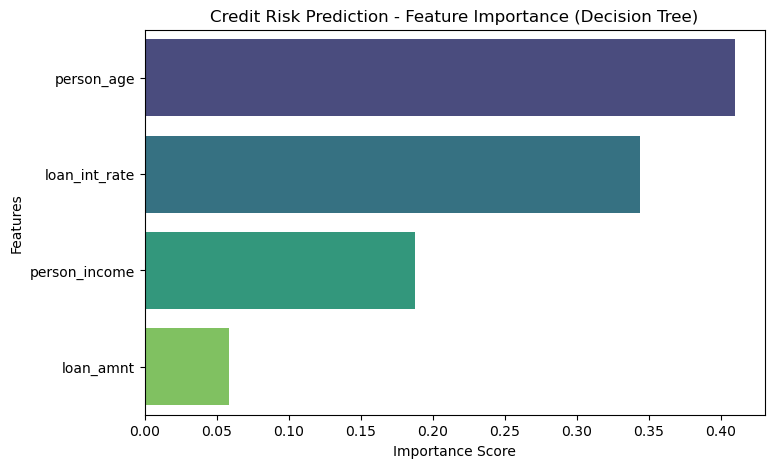

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = dt_model_smote.feature_importances_
features = X.columns

feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Credit Risk Prediction - Feature Importance (Decision Tree)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()